## algorithm design and anlysis-2026 spring  homework 1 
**Deadline**：2026.5.20

**name**: 冯炜玥


note：
---
1. 带有\*的题目，申请免上课的同学，必须完成，其他同学选作；
2. 请独立完成，如求助了他人或者大模型，请著明，并且不可省略算法分析部分；
4. 如若作答有雷同，全部取消成绩；
3. 需要书面作答的题目，可以通过引用图片的形式添加，但是注意上传项目时包含所引用的图片的源文件；
4. $log_n$ 默认表示$log_2{n}$;

## 问题 1

根据下列递归公式, 计算下列 $T(n)$ 对应的的渐近上界。要求所求的边界尽可能的紧（tight）, 请写明步骤。

1. $T(1)=1; T(n)=T(n/4)+1$ for $n>1$
2. $T(1)=1;T(n)=3T(n/3)+n^2$ for $n>1$
3. $T(1)=1;T(n)=T(2n/3)+1$ for $n>1$
4. $T(1)=1;T(n)=5T(n/4)+n$ for $n>1$
5. $T(n)=1 \ for\ n \le 2 ; T(n)=T(\sqrt{n})+1 \ for \ n>2$

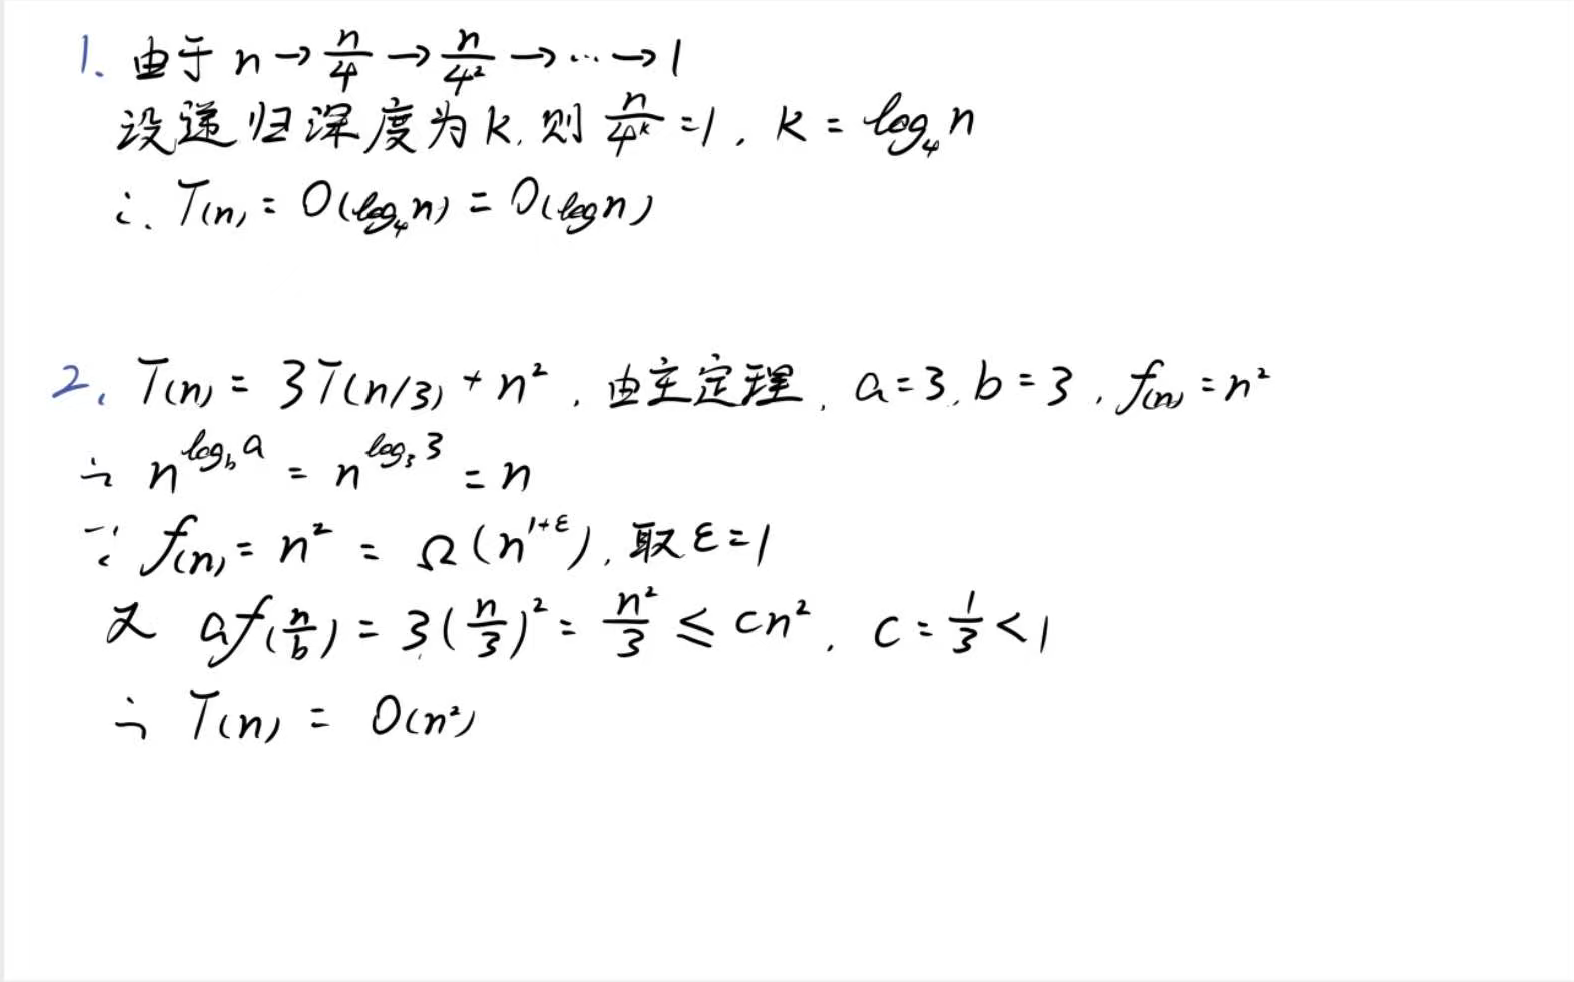

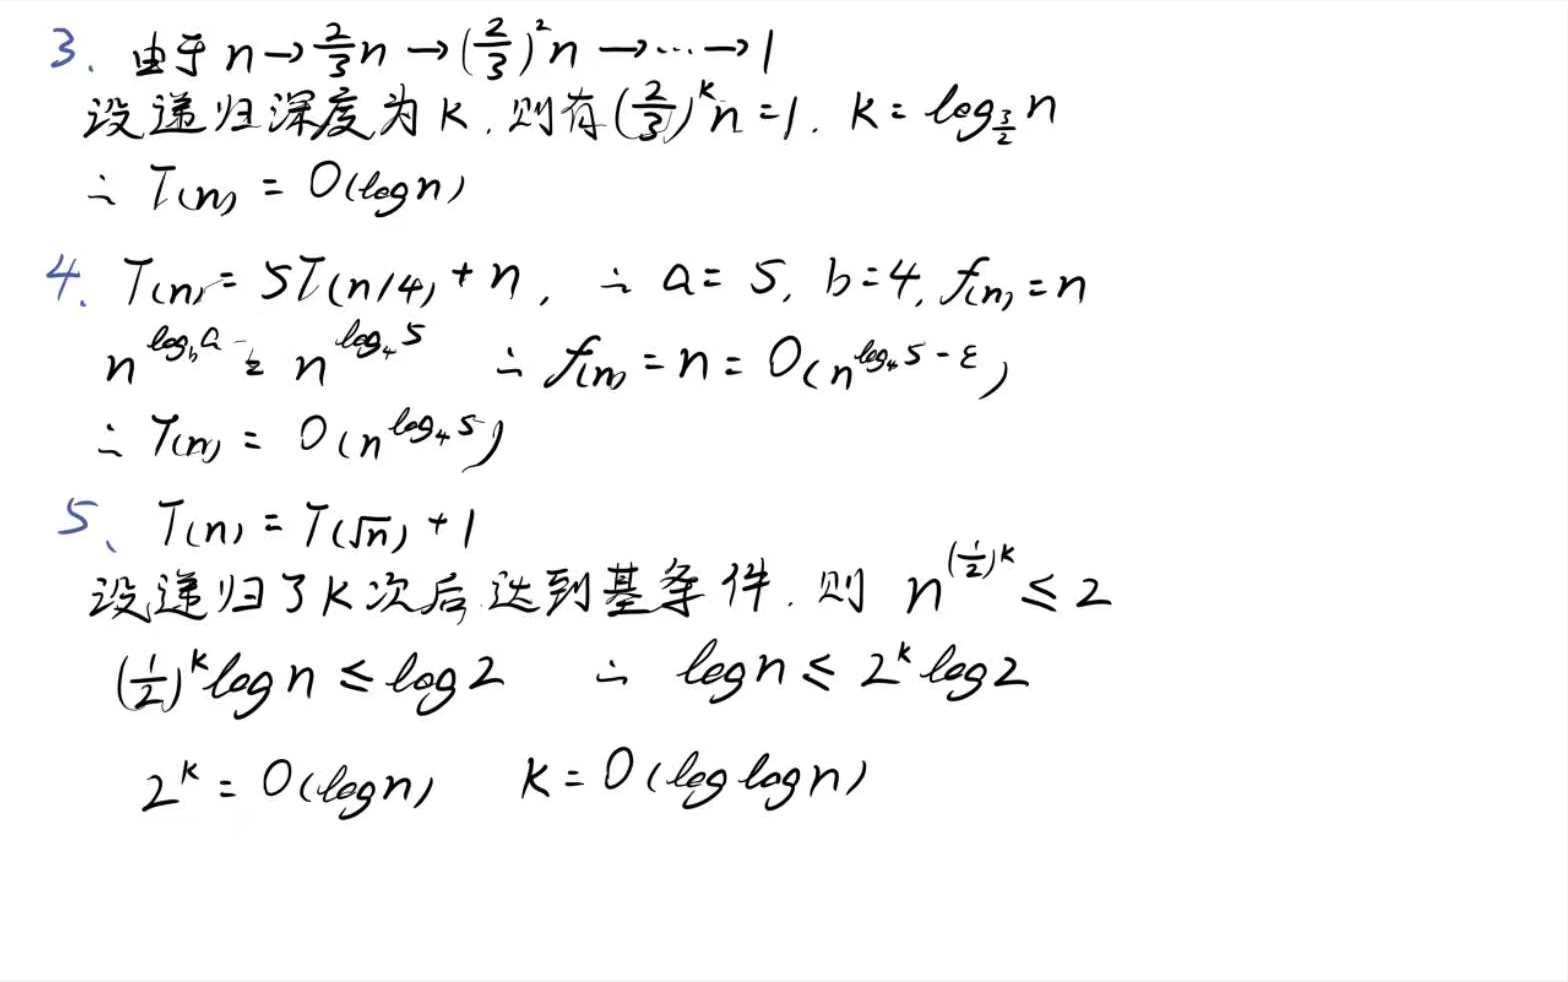

## 问题 2

观察下方的分治算法（divide-and-conquer algorithm）的伪代码, 回答下面问题

```latex
DoSomething(A,p,r)
-----
n := r-p+1
if n=2 and A[p]>A[r] then
    swap A[p] and A[r]
else if n >= 3 then
    m = ceil(2n/3)
    DoSomething(A,p,p+m-1)
    DoSomething(A,r-m+1,r)
    DoSomething(A,p,p+m-1)  
    
---
first call: DoSomething(A,1,n)
```

note：$ceil(2n/3)=\left\lceil {2n/3} \right\rceil$；$:=$ 表示赋值, 等价于 $\to$；A是一个包含n的整数元素的数组, 

1. 写出该算法时间复杂度的递归公式, 并求解其对应的渐进表示
2. 描述一下该算法的功能, 并判断是否是最高效的解决方案
3. \* 使用python编程实现上述算法或其对应的更高效版本的算法

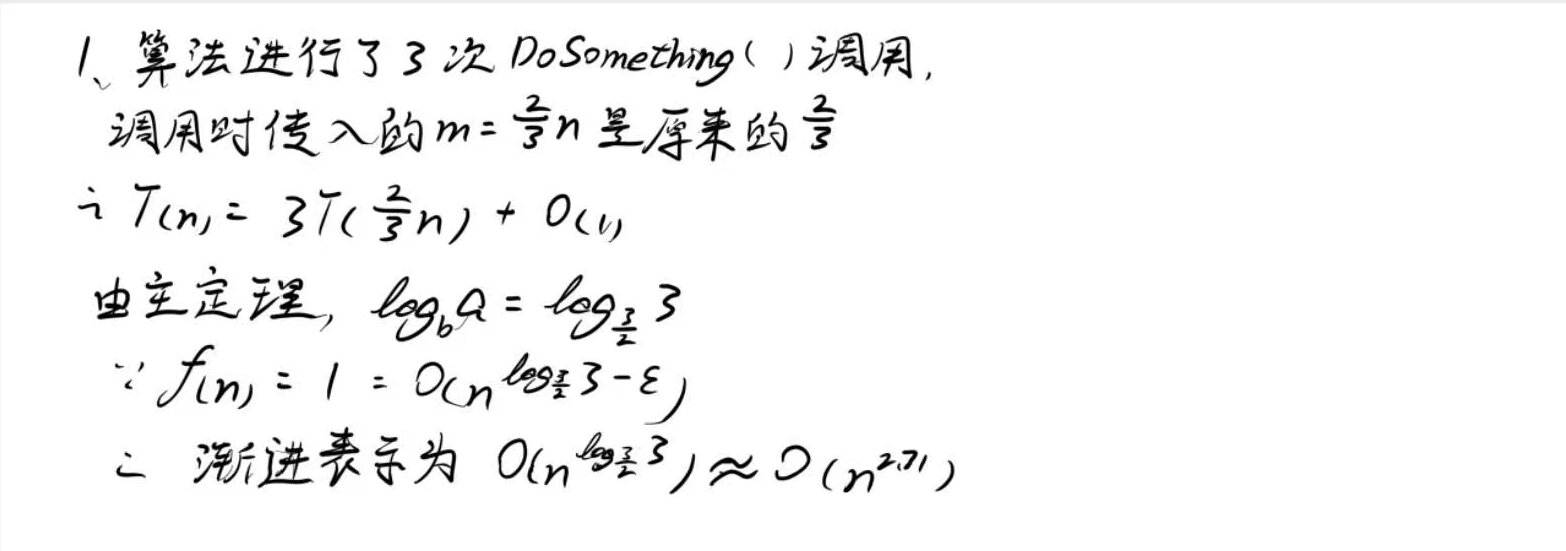

idea:2.该算法的功能是对数组进行升序排序，该算法的时间复杂度高于各种排序算法如冒泡、插入、归并排序等

In [3]:
# add your code here
def merge_sort(A):
    if len(A) <= 1:
        return A

    mid = len(A) // 2
    left = merge_sort(A[:mid])
    right = merge_sort(A[mid:])

    return merge(left, right)

def merge(left, right):
    result = []
    i = j = 0
    while i < len(left) and j < len(right):
        if left[i] <= right[j]:
            result.append(left[i])
            i += 1
        else:
            result.append(right[j])
            j += 1
    result.extend(left[i:])
    result.extend(right[j:])
    return result

# 测试
if __name__ == "__main__":
    arr1 = [5, 2, 9, 1, 5, 6]
    sorted_arr1 = merge_sort(arr1)
    print(f"Merge Sort 结果: {sorted_arr1}")
# your algorithm time complexity is:
# O(nlogn)

Merge Sort 结果: [1, 2, 5, 5, 6, 9]


## 问题 3

给定一个包含n个元素的数组 `profits` , 它的第 `i` 个元素 `profits[i]` 表示一支股票第 `i` 天的**收益**（正数表示涨, 负数表示跌）。你只能选择 **某一天** 买入这只股票, 并选择在 **未来的某一个不同的日子** 卖出该股票。

1. 设计一个算法来计算你所能获取的最大利润和对应买入和卖出的日期。请分析算法方案, 计算其时间复杂度, 并且使用python编程实现该算法。

2. \* 设计一个时间复杂度为 $O(n)$的算法实现该算法

e.g. :
---
profits=[3,2,1,-7,5,2,-1,3,-1], 第5天买入, 第8天卖出, 收益最大：9

idea: 该问题其实就是求数组profits的最大连续子数组和，因为从某一天买入并在之后某一天卖出，获得的总利润正好等于这段连续日期收益的累加和。简单的做法是枚举所有买入日期和卖出日期，用两层循环计算每一段区间收益，并不断更新最大利润及对应日期，时间复杂度为 (O(n^2))。为了优化到 (O(n))，可以采用动态规划思想，即Kadane算法：遍历数组时维护当前连续区间的累计收益current_sum，如果之前累计收益小于 0，说明它会拖累后续收益，应从当前天重新作为买入点开始计算；否则继续累加当前收益。同时维护全局最大收益max_profit，每当current_sum更大时，就更新最大利润以及对应的买入、卖出日期，这样只需一次遍历即可得到最优结果。


In [1]:
# add your code here
#1、
def max_profit_brute_force(profits):
    n = len(profits)
    max_profit = float('-inf')
    buy_date = -1
    sell_date = -1

    for i in range(n):
        current_sum = 0
        for j in range(i, n):
            current_sum += profits[j]
            if current_sum > max_profit:
                max_profit = current_sum
                buy_date = i + 1
                sell_date = j + 1

    return max_profit, buy_date, sell_date


# 2、
def max_profit_optimal(profits):
    if not profits:
        return 0, -1, -1

    n = len(profits)
    max_profit = float('-inf')
    current_sum = 0

    buy_date = 0
    sell_date = 0
    temp_buy = 0

    for i in range(n):
        if current_sum < 0:
            current_sum = profits[i]
            temp_buy = i
        else:
            current_sum += profits[i]

        if current_sum > max_profit:
            max_profit = current_sum
            buy_date = temp_buy
            sell_date = i

    return max_profit, buy_date + 1, sell_date + 1

# 测试
if __name__ == "__main__":
    profits_example = [3, 2, 1, -7, 5, 2, -1, 3, -1]

    max_p, buy_d, sell_d = max_profit_optimal(profits_example)

    print(f"profits={profits_example}")
    print(f"第{buy_d}天买入，第{sell_d}天卖出，收益最大：{max_p}")
# your algorithm time complexity is:
# 1、O(n^2)  2、O(n)

--- 测试 O(n) 高效算法 ---
profits=[3, 2, 1, -7, 5, 2, -1, 3, -1]
第5天买入，第8天卖出，收益最大：9


## 问题 4

给定一个包含不同整数元素的数组 $ A[1..n]$ ,并且满足条件：$A[1]>A[2]$ 并且 $A[n-1]<A[n]$; 规定：如果一个元素比它两边的邻居元素都小, 即：$A[x]<A[x-1], A[x]<A[x+1]$ , 称这个元素A[x]为“局部最小”。通过遍历一次数组, 我们可以很容易在 $O(n)$的时间复杂度下找到一个局部最小值, 


1. 分析该问题, 设计一个算法在$O(logn)$的时间复杂度下找到一个局部最小(返回数值), 要求：分析算法设计思路, 并且使用python编程实现
2. \* 设计算法找出所有局部最小值, 分析算法设计思路, 并使用python编程实现

e.g.:
---
A=[9, 3, 7, 2, 1, 4, 5 ] 时,  局部最小元素为 3, 1

idea:1、可以用二分查找的思想，如果 A[mid] < A[mid-1] 且 A[mid] < A[mid+1]，那么 mid 就是一个局部最小，直接返回；如果A[mid] > A[mid+1]，由于A[n-2] < A[n-1]，那么在 [mid+1, n-1] 这个区间内必定存在一个局部最小；如果A[mid] < A[mid+1]，由于A[0] > A[1]，那么[0, mid-1] 这个区间内必定存在一个局部最小。
2、要找出所有局部最小值，可以用线性查找依次寻找

In [6]:
# add your code here
def find_one_local_minimum(A):

    n = len(A)
    # 在1到n-2之间找
    left, right = 1, n - 2

    while left <= right:
        mid = left + (right - left) // 2

        if A[mid] < A[mid - 1] and A[mid] < A[mid + 1]:
            return A[mid]

        if A[mid] > A[mid + 1]:
            left = mid + 1
        else:
            right = mid - 1

    return None

# 测试
A = [9, 3, 7, 2, 1, 4, 5]
print("找到的一个局部最小值为:", find_one_local_minimum(A))
# your algorithm time complexity is:
# O(log_n)

2.
def find_all_local_minima(A):

    n = len(A)
    result = []

    # 局部最小值不可能在首尾，直接遍历中间的元素
    for i in range(1, n - 1):
        if A[i] < A[i - 1] and A[i] < A[i + 1]:
            result.append(A[i])

    return result

# 测试
A = [9, 3, 7, 2, 1, 4, 5]
print("所有的局部最小值为:", find_all_local_minima(A))

# your algorithm time complexity is:
# 2、O(n)

找到的一个局部最小值为: 1
所有的局部最小值为: [3, 1]


## 问题 5

给定包含n个不同数字的一组数, 寻找一种基于比较的算法在这组数中找到k个最小的数字, 并按顺序输出它们。

1. 将n个数先进行排序, 然后按顺序输出最小的k个数。要求：选择合适的排序算法实现上述操作, 计算算法时间复杂度, 并使用python编程实现。
2. 建立一个包含这n个数的堆（heap）, 并且调用 k 次Extract-min 按顺序输出最小的k个数。使用往空堆中不断插入元素的方法建立堆, 分析这种方法建堆的时间复杂度, 并使用python编程实现
3. \* 假设数组中包含的数据总数目超过了计算机的存储能力, 请设计一个算法, 找到这堆数据的前k小的数值, 计算时间复杂度, 并使用python实现该算法, 假设计算机一定能存储k个数据。

e.g.：
---
数组arr=[5,4,3,2,6,1,88,33,22,107] 的前3个最小数据为：1, 2, 3

idea:1、用快速排序
2、向一个大小为 $i$ 的堆中插入一个新元素的时间复杂度是 $O(\log i)$。将 $n$ 个元素逐个插入空堆中，总时间消耗为 $\sum_{i=1}^{n} \log i = \log(n!)$。时间复杂度为 $O(n \log n)$。每次 Extract-min 操作（弹出堆顶并调整堆）的时间复杂度为 $O(\log n)$。执行 $k$ 次，时间复杂度为 $O(k \log n)$。综合时间复杂度为 $O(n \log n + k \log n) = O(n \log n)$。

In [30]:
# add your code here
1.
def quick_sort(arr):
    if len(arr) <= 1:
        return arr

    pivot = arr[len(arr) // 2]

    left = [x for x in arr if x < pivot]
    middle = [x for x in arr if x == pivot]
    right = [x for x in arr if x > pivot]

    return quick_sort(left) + middle + quick_sort(right)


# 测试
nums = [5, 4, 3, 2, 6, 1, 88, 33, 22, 107]
k = 3

# 快速排序
sorted_nums = quick_sort(nums)

# 输出前k个最小元素
print("最小的", k, "个数字为：")
print(sorted_nums[:k])

2.
import heapq

def top_k_by_min_heap(arr, k):
    if k <= 0 or not arr:
        return []

    min_heap = []

    for num in arr:
        heapq.heappush(min_heap, num)

    result = []
    for _ in range(min(k, len(arr))):
        result.append(heapq.heappop(min_heap))

    return result

# 测试
arr = [5, 4, 3, 2, 6, 1, 88, 33, 22, 107]
print("2. 最小堆插入法结果:", top_k_by_min_heap(arr, 3))
# your algorithm time complexity is:
# 1、O(nlogn)

最小的 3 个数字为：
[1, 2, 3]
2. 最小堆插入法结果: [1, 2, 3]


## 问题 6

> 星球碰撞问题：现有n个星球，在同一条直线上运行，如数组A所示，元素的绝对值表示星球的质量，负数表示星球自右向左运动，正数表示星球自左向右运动，当两个星球相撞的时候，质量小的会消失，大的保持不变，**质量相同的两个星球碰撞后自右向左运动的星球消失，自左向右的星球保持不变**，假设所有星球的速度大小相同。
>
> $ A=[23,-8, 9, -3, -7, 9, -23, 22] $

请设计一个算法模拟星球的运行情况，输出最终的星球存续情况（输出一个数组），分析算法设计思路，计算时间复杂度，并基于python编程实现。

e.g.
---
1.  输入： A=[-3,-6,2,8, 5,-8,9,-2,1]， 输出：[-3, -6, 2, 8, 9, 1]

2. 输入：A=[23,-8, 9, -3, -7, 9, -23, 22], 输出：[23, 22]

idea:用栈来模拟。不发生碰撞的情况： 如果栈为空，或者当前星球向右运行（$p > 0$），或者栈顶星球也是向左运行（栈顶元素 $< 0$），那么当前星球绝对不会和栈中现存的星球发生碰撞。此时直接将 $p$ 压入栈中。发生碰撞的情况： 如果当前星球向左运行（$p < 0$），而栈顶星球向右运行（栈顶元素 $> 0$），必然发生碰撞。我们需要进行质量（绝对值）的比对：如果 当前星球质量 $>$ 栈顶星球质量（abs(p) > stack[-1]）：栈顶星球被撞毁（弹出栈）。由于当前星球还在继续向左飞行，它可能还会撞毁栈中更底下的其他星球，所以需要继续循环比较。如果 当前星球质量 $==$ 栈顶星球质量（abs(p) == stack[-1]）：根据题目特殊规定，“自右向左运动的星球消失，自左向右的星球保持不变”。这意味着当前星球 $p$（负数）消失，栈顶星球（正数）得以保留。此时碰撞结束，当前星球无需入栈。如果 当前星球质量 $<$ 栈顶星球质量（abs(p) < stack[-1]）：当前星球 $p$ 直接被撞毁，栈顶星球保持不变。碰撞结束，当前星球无需入栈。

In [20]:
# add your code here
def planet_collision(A):
    stack = []

    for p in A:
        alive = True

        while alive and p < 0 and stack and stack[-1] > 0:

            if abs(p) > stack[-1]:
                stack.pop()

            elif abs(p) == stack[-1]:
                alive = False

            else:
                alive = False

        if alive:
            stack.append(p)

    return stack

# 测试

A1 = [-3, -6, 2, 8, 5, -8, 9, -2, 1]
print(f"输入: {A1}")
print(f"输出: {planet_collision(A1)}")
print("-" * 30)

A2 = [23, -8, 9, -3, -7, 9, -23, 22]
print(f"输入: {A2}")
print(f"输出: {planet_collision(A2)}")
# your algorithm time complexity is:
# O(n)


输入: [-3, -6, 2, 8, 5, -8, 9, -2, 1]
输出: [-3, -6, 2, 8, 9, 1]
------------------------------
输入: [23, -8, 9, -3, -7, 9, -23, 22]
输出: [23, 22]


## 问题 7

> 0-1背包问题：现在有4块大理石，每个大理石对应的重量和价值使用一个元组表示, 即（重量，价值），4块大理石的重量和价值为：[(5,10), (4,40), (6,30), (3, 50)], 假设你有一辆最大承重为9的小推车，请问使用这个小推车装大理石的最大价值为多少

请设计一个算法解决该问题，分析算法设计思路，计算时间复杂度，并基于python编程实现

idea:状态转移方程：对于每一块大理石（假设其重量为 $w$，价值为 $v$），我们遍历推车的所有可能容量 $j$（从最大承重 $W$ 递减到 $w$）。在容量 $j$ 下，我们有两个选择：不装这块大理石： 价值保持为 $dp[j]$。装入这块大理石： 价值变为 当前大理石的价值 + 剩余容量所能装载的最大价值，即 $v + dp[j - w]$。

In [21]:
# add your code here
def knapsack_01(items, capacity):
    dp = [0] * (capacity + 1)

    for weight, value in items:
        for j in range(capacity, weight - 1, -1):
            # 比较“不装入”和“装入”当前大理石的价值，取最大值
            dp[j] = max(dp[j], dp[j - weight] + value)

    return dp[capacity]

marbles = [(5, 10), (4, 40), (6, 30), (3, 50)]
max_capacity = 9

max_value = knapsack_01(marbles, max_capacity)

print(f"小推车装大理石的最大价值为: {max_value}")

# your algorithm time complexity is:
# O(9n)

小推车装大理石的最大价值为: 90


## 问题 8

给你二叉搜索树的根节点 root ，该树中的恰好两个节点的值被错误地交换。请在不改变其结构的情况下，恢复这棵树 。设计算法解决该问题，分析算法设计思路，计算时间复杂度，并基于python编程实现

e.g.:
---
1.

<div style="text-align:center;width:200px;"> <img alt="" src="./fig/hw3q9-1.jpg"> </div>
输入：root = [1,3,null,null,2]， 输出为：[3,1,null,null,2]， 

解释：3 不能是 1 的左孩子，因为 3 > 1 。交换 1 和 3 使二叉搜索树有效。

2.

 <div style="text-align:center;width:200px;"> <img alt="" src="./fig/hw3q9-1.jpg"> </div>
输入： root=[3,1,4,null,null,2]， 输出为：[2,1,4,null,null,3]

解释：2 不能在 3 的右子树中，因为 2 < 3 。交换 2 和 3 使二叉搜索树有效。

idea:利用二叉搜索树（BST）中序遍历结果应当是严格递增序列这一性质。正常情况下，对BST进行中序遍历时，当前节点的值一定大于前一个访问节点的值；如果有两个节点被错误交换，那么中序序列中就会出现“逆序对”。因此，在中序遍历过程中维护一个前驱节点prev，当发现prev.val > node.val时，说明出现了异常：第一次出现逆序时，将前驱节点记录为第一个错误节点first；之后每次出现逆序，都将当前节点记录为第二个错误节点second。遍历结束后，交换first和second的值即可恢复整棵二叉搜索树，而不需要改变树的结构。

In [25]:
# add your code here

class TreeNode:
    def __init__(self, val=0, left=None, right=None):
        self.val = val
        self.left = left
        self.right = right

class Solution:
    def recoverTree(self, root: TreeNode) -> None:

        self.first = None
        self.second = None
        self.prev = TreeNode(float('-inf'))

        def inorder(node: TreeNode):
            if not node:
                return

            inorder(node.left)

            if self.prev.val > node.val:
                if not self.first:
                    self.first = self.prev
                self.second = node

            self.prev = node

            inorder(node.right)

        inorder(root)

        if self.first and self.second:
            self.first.val, self.second.val = self.second.val, self.first.val


def build_tree(arr):
 # 将层序遍历的数组转换为二叉树
    if not arr or arr[0] is None:
        return None

    root = TreeNode(arr[0])
    queue = deque([root])
    i = 1

    while queue and i < len(arr):
        node = queue.popleft()

        if i < len(arr) and arr[i] is not None:
            node.left = TreeNode(arr[i])
            queue.append(node.left)
        i += 1

        if i < len(arr) and arr[i] is not None:
            node.right = TreeNode(arr[i])
            queue.append(node.right)
        i += 1

    return root

def tree_to_array(root):
# 将二叉树转换为层序遍历的数组格式
    if not root:
        return []

    res = []
    queue = deque([root])

    while queue:
        node = queue.popleft()
        if node:
            res.append(node.val)
            queue.append(node.left)
            queue.append(node.right)
        else:
            res.append(None)

    while res and res[-1] is None:
        res.pop()

    return res

def format_output(arr):
    return "[" + ",".join(["null" if x is None else str(x) for x in arr]) + "]"


# 测试

sol = Solution()

# 示例 1
input_arr_1 = [1, 3, None, None, 2]
root_1 = build_tree(input_arr_1)
sol.recoverTree(root_1)
output_arr_1 = tree_to_array(root_1)

print("e.g 1:")
print(f"输入: root = {format_output(input_arr_1)}, 输出为: {format_output(output_arr_1)}")
print("-" * 50)

# 示例 2
input_arr_2 = [3, 1, 4, None, None, 2]
root_2 = build_tree(input_arr_2)
sol.recoverTree(root_2)
output_arr_2 = tree_to_array(root_2)

print("e.g 2:")
print(f"输入: root = {format_output(input_arr_2)}, 输出为: {format_output(output_arr_2)}")
# your algorithm time complexity is:

示例 1:
输入: root = [1,3,null,null,2], 输出为: [3,1,null,null,2]
--------------------------------------------------
示例 2:
输入: root = [3,1,4,null,null,2], 输出为: [2,1,4,null,null,3]


## 问题 9 \*
给定 `n` 个非负整数表示每个宽度为 `1` 的柱子的高度图，计算按此排列的柱子，下雨之后能接多少雨水。



<div style="text-align:center;width:800px;"> <img alt="" src="./fig/hw3q6.png"> </div>

请分析算法设计思路，计算时间复杂度，并基于python编程实现

idea:某个点所能积攒的雨水量由它左边和右边更矮的一方决定，可以用双指针法

In [28]:
# add your code here
def trap(height: list[int]) -> int:
    if not height:
        return 0

    left, right = 0, len(height) - 1
    left_max, right_max = 0, 0
    total_water = 0

    while left < right:
        if height[left] < height[right]:
            if height[left] >= left_max:
                left_max = height[left]
            else:
                total_water += left_max - height[left]
            left += 1
        else:
            if height[right] >= right_max:
                right_max = height[right]
            else:
                total_water += right_max - height[right]
            right -= 1

    return total_water

# 示例测试
print(trap([0,1,0,2,1,0,1,3,2,1,2,1])) # 输出: 6
print(trap([4,2,0,3,2,5]))             # 输出: 9
# your algorithm time complexity is:
# O(n)

6
9


## 问题 10

给你一个二叉树的根节点 root ，树中每个节点都存放有一个 0 到 9 之间的数字。每条从根节点到叶节点的路径都代表一个数字：

> 例如，从根节点到叶节点的路径 1 -> 2 -> 3 表示数字 123 。

设计一个算法计算从根节点到叶节点生成的所有数字之和 ，分析算法设计思路，计算时间复杂度，并基于python编程实现

叶节点:是指没有子节点的节点。

e.g.:
---
1.

 <div style="text-align:center;width:200px;"> <img alt="figure" src="./fig/hw3q10-1.jpg"> </div>

 输入：root = [1,2,3], 输出：25

解释：从根到叶子节点路径 1->2 代表数字 12，1->3 代表数字 13，因此和为 12 + 13 = 25 。

2.

 <div style="text-align:center;width:200px;"> <img alt="figure" src="./fig/hw3q10-2.jpg"> </div>

 输入：root = [4,9,0,5,1], 输出：1026

解释：从根到叶子节点路径 4->9->5 代表数字 495，4->9->1 代表数字 491，4->0 代表数字 40。因此和为 495 + 491 + 40 = 1026 。

idea:从根节点开始向下搜索，每经过一个节点，就将当前路径形成的数字更新为 current_sum * 10 + node.val，相当于把当前节点的数字拼接到原数字末尾。当递归到叶子节点时，说明已经得到了一条完整的根到叶路径对应的数字，此时直接返回该值；否则继续递归左右子树，并将左右子树得到的结果求和。

In [24]:
# add your code here
from collections import deque

class TreeNode:
    def __init__(self, val=0, left=None, right=None):
        self.val = val
        self.left = left
        self.right = right

class Solution:
    def sumNumbers(self, root: TreeNode) -> int:

        def dfs(node, current_sum):
            if not node:
                return 0

            current_sum = current_sum * 10 + node.val

            if not node.left and not node.right:
                return current_sum

            left_sum = dfs(node.left, current_sum)
            right_sum = dfs(node.right, current_sum)

            return left_sum + right_sum

        return dfs(root, 0)

def build_tree(arr):
    if not arr or arr[0] is None:
        return None
    root = TreeNode(arr[0])
    queue = deque([root])
    i = 1
    while queue and i < len(arr):
        node = queue.popleft()
        if i < len(arr) and arr[i] is not None:
            node.left = TreeNode(arr[i])
            queue.append(node.left)
        i += 1
        if i < len(arr) and arr[i] is not None:
            node.right = TreeNode(arr[i])
            queue.append(node.right)
        i += 1
    return root

# 测试
sol = Solution()

root1 = build_tree([1, 2, 3])
res1 = sol.sumNumbers(root1)
print(f"e.g 1 输入: [1, 2, 3] -> 输出: {res1}")

root2 = build_tree([4, 9, 0, 5, 1])
res2 = sol.sumNumbers(root2)
print(f"e.g 2 输入: [4, 9, 0, 5, 1] -> 输出: {res2}")
# your algorithm time complexity is:
# O(n)

示例 1 输入: [1, 2, 3] -> 输出: 25
示例 2 输入: [4, 9, 0, 5, 1] -> 输出: 1026
